In [36]:
import pandas as pd
import numpy as np
import databento as db
import datetime
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
import exchange_calendars as ec

def is_full_nyse_day(date):
    nyse = ec.get_calendar("XNYS")
    date = pd.Timestamp(date).normalize()

    # Check if it's a trading session at all
    if not nyse.is_session(date):
        return False

    open_time = nyse.session_open(date)
    close_time = nyse.session_close(date)

    # A "full" NYSE day runs 6.5 hours (09:30–16:00 ET)
    full_length = pd.Timedelta(hours=6.5)
    return (close_time - open_time) >= full_length


In [37]:
def process_data(daily_df):

    daily_df["weighted_mid"] = (
    daily_df["bid_px_00"] * daily_df["ask_sz_00"] + daily_df["ask_px_00"] * daily_df["bid_sz_00"]
        ) / (daily_df["bid_sz_00"] + daily_df["ask_sz_00"])

    daily_df["weighted_mid"] = daily_df["weighted_mid"].ffill()
    daily_df = daily_df.sort_index()
    daily_df = daily_df.resample("1s").ffill()

    daily_df["ret_1s"] = daily_df["weighted_mid"].pct_change()
    daily_df["ret_sq"] = daily_df["ret_1s"] ** 2
    rv_60s = daily_df["ret_sq"].resample("60s", label="right", closed="right").apply(lambda x: x.iloc[0:59].sum())

    daily_df["rv_60s"] = rv_60s.reindex(daily_df.index, method="ffill")
    ret_1min = daily_df["weighted_mid"].resample("60s", label="right", closed="right").last().pct_change()
    daily_df["ret_60s"] = ret_1min.reindex(daily_df.index, method="ffill")
    first_date = daily_df.index[0].normalize()
    session_start = first_date + pd.Timedelta(hours=8, minutes=1)
    daily_df = daily_df[daily_df.index >= session_start]
    df_1min = daily_df[daily_df.index.second == 0].copy()
    return df_1min


In [38]:
file = r"C:\Users\MainUser\cs230\BernsteinMartingaleNet\MarketData\xnas-itch-20250220.bbo-1s.dbn.zst"
data = db.DBNStore.from_file(file)
jingshu_df= process_data(data.to_df()).reset_index()
date_str = file.split("-")[2].split(".")[0]
open_time = datetime.datetime.strptime(date_str + " 09:31:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
close_time = datetime.datetime.strptime(date_str + " 16:00:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
jingshu_df["ts_recv"] = pd.to_datetime(jingshu_df["ts_recv"])
jingshu_df['ts_recv_est'] = jingshu_df['ts_recv'].dt.tz_convert('America/New_York')
jingshu_df = jingshu_df[(jingshu_df["ts_recv_est"] >= open_time) & (jingshu_df["ts_recv_est"] <= close_time)]
jingshu_df["seconds_since_open"] = (jingshu_df["ts_recv_est"] - open_time).dt.total_seconds()
print(jingshu_df.head())

                      ts_recv                            ts_event  rtype  \
330 2025-02-20 14:31:00+00:00 2025-02-20 14:30:57.534871264+00:00    195   
331 2025-02-20 14:32:00+00:00 2025-02-20 14:31:59.956130294+00:00    195   
332 2025-02-20 14:33:00+00:00 2025-02-20 14:32:59.686332016+00:00    195   
333 2025-02-20 14:34:00+00:00 2025-02-20 14:33:59.674954421+00:00    195   
334 2025-02-20 14:35:00+00:00 2025-02-20 14:34:59.461201853+00:00    195   

     publisher_id  instrument_id side   price  size  flags  sequence  ...  \
330             2          15144    B  611.59   100    130  31428563  ...   
331             2          15144    A  611.57    25    128  34575463  ...   
332             2          15144    A  611.52    71    130  37046273  ...   
333             2          15144    A  611.24     1    130  39453365  ...   
334             2          15144    A  611.24   500    130  41648264  ...   

     bid_ct_00  ask_ct_00  symbol  weighted_mid    ret_1s        ret_sq  \
330  

In [39]:
def jayeoon_get_data(file):
    data = db.DBNStore.from_file(file)
    df = data.to_df()
    date_str = file.split("-")[2].split(".")[0]
    open_time = datetime.datetime.strptime(date_str + " 09:30:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
    close_time = datetime.datetime.strptime(date_str + " 16:00:00", "%Y%m%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
    df["ts_recv"] = pd.to_datetime(df.index)
    df['ts_recv_est'] = df['ts_recv'].dt.tz_convert('America/New_York')
    df = df[(df["ts_recv_est"] >= open_time) & (df["ts_recv_est"] <= close_time)]
    df["seconds_since_open"] = (df["ts_recv_est"] - open_time).dt.total_seconds()
    df["weighted_mid"] = (
        df["bid_px_00"] * df["ask_sz_00"] + df["ask_px_00"] * df["bid_sz_00"]
        ) / (df["bid_sz_00"] + df["ask_sz_00"])
    mids = np.array(df["weighted_mid"].resample("1s").ffill())
    returns = (mids[60::60] - mids[:-60:60]) / mids[:-60:60]
    log_prices = np.log(mids)
    rv = [np.sum((np.diff(mids[60 * i: 60 * (i+1)]) / mids[60 * i: 60 * (i+1) - 1]) ** 2) for i in range(len(log_prices) // 60)]
    rv = np.array(rv)
    return np.vstack([rv, returns])

Text(0.5, 1.0, 'rv')

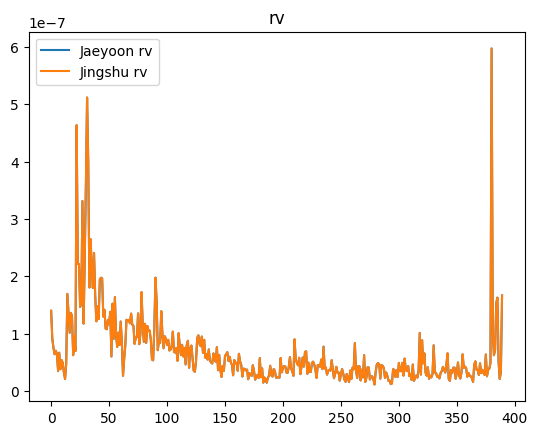

In [40]:
rv, returns = jayeoon_get_data(file)
plt.plot(rv, label="Jaeyoon rv")
plt.plot(np.array(jingshu_df["rv_60s"]), label="Jingshu rv")
plt.legend()
plt.title("rv")

Text(0.5, 1.0, 'returns')

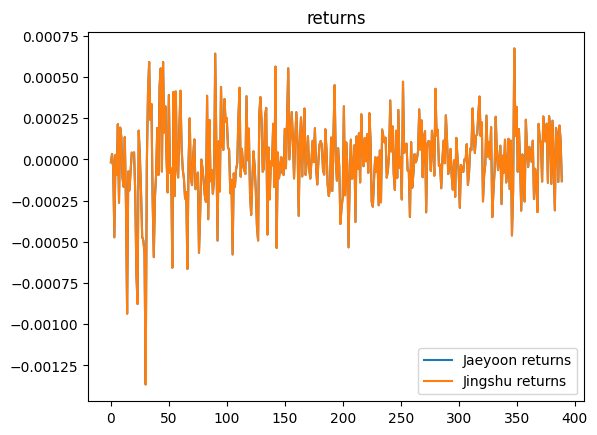

In [41]:
plt.plot(returns, label="Jaeyoon returns")
plt.plot(np.array(jingshu_df["ret_60s"]), label="Jingshu returns")
plt.legend()
plt.title("returns")

In [42]:
assert(len(jingshu_df) == len(returns))
diff = returns[:len(jingshu_df)] - jingshu_df["ret_60s"].values[:len(returns)]
print("Mean diff:", diff.mean())
print("Max diff:", diff.max())
print("Min diff:", diff.min())

Mean diff: -2.1623422224723823e-18
Max diff: 1.1061572664783359e-16
Min diff: -1.1066993675645787e-16


In [43]:
assert(len(jingshu_df) == len(returns))
diff = rv[:len(jingshu_df)] - jingshu_df["rv_60s"].values[:len(returns)]
print("Mean diff:", diff.mean())
print("Max diff:", diff.max())
print("Min diff:", diff.min())

Mean diff: -3.327896072615904e-22
Max diff: 1.2602262068367887e-19
Min diff: -8.872670122488796e-20
